# Tutorial: validating a Landlab field against observations

This notebook runs on its own. It makes a small example dataset first, so you can
execute every cell before you have your own data ready.

The whole package is one idea:

```text
your file  ->  a field on the grid  ->  say what it means  ->  compare  ->  plot
```

Install, if you have not already:

```bash
pip install "landlab-grid-validation[io,plot] @ git+https://github.com/Almehedi06/landlab_grid_validation"
```

In [1]:
import numpy as np

from landlab_grid_validation import (
    FieldSpec,
    compare_fields_on_grid,
    grid_from_raster,
    plot_comparison,
    raster_to_node_field,
    vector_to_node_field,
)

## Step 0. A small example dataset

Three files, the same three you will have in real work:

| file | what it is |
|---|---|
| `model.tif` | what the model predicts: a probability between 0 and 1 |
| `points.shp` | what was observed in the field: mapped initiation points |
| `ddem.tif` | elevation change, metres, negative where ground was lost |

Skip this cell once you use your own files.

In [2]:
from pathlib import Path
import tempfile

import geopandas as gpd
import rasterio
from rasterio.transform import from_origin
from shapely.geometry import Point

FOLDER = Path(tempfile.mkdtemp(prefix="lgv_tutorial_"))
CRS = "EPSG:32610"          # UTM zone 10N; any projected CRS in metres works
CELL = 10.0                 # metre cells
ROWS, COLS = 60, 60
transform = from_origin(500000.0, 5300000.0, CELL, CELL)   # top-left corner
rng = np.random.default_rng(7)


def write(name, values, nodata=None):
    path = FOLDER / name
    with rasterio.open(path, "w", driver="GTiff", height=ROWS, width=COLS, count=1,
                       dtype="float32", crs=CRS, transform=transform, nodata=nodata) as dst:
        dst.write(values.astype("float32"), 1)
    return path


# A model probability that is high in two patches and low elsewhere.
row, col = np.mgrid[0:ROWS, 0:COLS]
hot = np.exp(-((row - 18) ** 2 + (col - 20) ** 2) / 90) + np.exp(-((row - 42) ** 2 + (col - 38) ** 2) / 60)
probability = np.clip(0.15 * rng.random((ROWS, COLS)) + 0.85 * hot, 0, 1)
model_path = write("model.tif", probability)

# Observations: 40 points, mostly where the model is high, a few anywhere.
weights = (probability ** 3).ravel() / (probability ** 3).sum()
picked = rng.choice(ROWS * COLS, size=32, replace=False, p=weights)
picked = np.r_[picked, rng.choice(ROWS * COLS, size=8, replace=False)]
pr, pc = np.unravel_index(picked, (ROWS, COLS))
xs = 500000.0 + (pc + 0.5) * CELL
ys = 5300000.0 - (pr + 0.5) * CELL
points_path = FOLDER / "points.shp"
gpd.GeoDataFrame({"id": np.arange(picked.size)},
                 geometry=[Point(x, y) for x, y in zip(xs, ys)], crs=CRS).to_file(points_path)

# Elevation change: ground lost at most of the points, plus survey noise and a
# couple of places that eroded without being mapped. Real surveys look like this.
loss = np.zeros((ROWS, COLS))
seen = rng.random(picked.size) < 0.7
loss[pr[seen], pc[seen]] = -rng.uniform(0.4, 1.4, seen.sum())
elsewhere = rng.choice(ROWS * COLS, size=25, replace=False)
loss.ravel()[elsewhere] -= rng.uniform(0.3, 0.9, elsewhere.size)
dz = loss + rng.normal(0, 0.3, (ROWS, COLS))
ddem_path = write("ddem.tif", dz, nodata=-9999.0)

print("example data in", FOLDER)
for p in sorted(FOLDER.glob("*")):
    print("  ", p.name)

example data in /tmp/lgv_tutorial_uojuyvbg
   ddem.tif
   model.tif
   points.cpg
   points.dbf
   points.prj
   points.shp
   points.shx


## Step 1. One grid for everything

Every layer is compared on a single Landlab grid. Build it from one raster, and
that raster's grid becomes the reference.

**Always use `grid_from_raster`.** Landlab's own ASCII loader puts nodes on cell
corners for files written with `XLLCORNER`, which shifts everything by half a
cell. In our Pioneer work that silently moved 73 of 89 points into the wrong cell.

In [3]:
grid, crs = grid_from_raster(model_path, crs=CRS)
print("grid:", grid.number_of_node_rows, "rows x", grid.number_of_node_columns, "columns")
print("cell size:", grid.dx, "m   nodes:", grid.number_of_nodes)

grid: 60 rows x 60 columns
cell size: 10.0 m   nodes: 3600


## Step 2. Put each file on the grid

A Landlab grid carries no coordinate system, so you state the CRS. Nothing is guessed.

If a file is on a different grid or resolution, you must say how to resample it:
`"average"` suits depths, `"nearest"` or `"mode"` suit classes and yes/no maps.

In [4]:
predicted = raster_to_node_field(grid, crs, model_path, raster_crs=CRS)
observed = vector_to_node_field(grid, crs, points_path)
elevation_change = raster_to_node_field(grid, crs, ddem_path, raster_crs=CRS)

print("cells holding a point:", int(np.nansum(observed)))
print("predicted probability range: %.2f to %.2f" % (np.nanmin(predicted), np.nanmax(predicted)))

cells holding a point: 40
predicted probability range: 0.00 to 0.99


## Step 3. Say what each layer means

A number alone is ambiguous: `1` could be a landslide, a class code or a metre of
erosion. `FieldSpec` carries the little bit of meaning needed to compare two layers
without guessing.

- `kind="continuous"` for probabilities, depths, elevation change
- `kind="binary"` for yes/no maps
- `kind="categorical"` for class codes, with a `classes` mapping

`threshold` is what counts as "yes" for a continuous layer. There is no default:
choosing it is your decision, not the software's.

In [5]:
model_spec = FieldSpec(name="modelled probability", kind="continuous",
                       units="probability", threshold=0.5)
points_spec = FieldSpec(name="mapped points", kind="binary")

## Step 4. Compare

One call. It checks the values first: probabilities must sit inside [0, 1], binary
layers may hold only 0 and 1, categorical layers only their declared codes. Bad
values stop the run instead of quietly scoring.

In [6]:
result = compare_fields_on_grid(grid, predicted, observed, model_spec, points_spec)
print(result.comparison_type, "over", int(result.valid_mask.sum()), "cells")

probability_vs_binary over 3600 cells


## Step 5. Read the numbers

`result.metrics` is a plain dictionary, so you can print it, save it or add your own.

The ones that matter most here:

- **roc_auc** — can the model rank observed cells above unobserved ones? 0.5 is a coin flip.
- **roc_auc_ci_low / high** — the 95% confidence interval. **Compare intervals, not
  just AUC values.** If two models' intervals overlap, you cannot say one is better.
- **recall** — how many observed cells the model caught at your threshold.
- **precision** — how often it was right when it said yes.
- **average_precision** — like precision and recall combined, good when yes cells are rare.

The interval assumes cells are independent. Real mapped points cluster together, so
treat it as the smallest the uncertainty could be, not the whole of it.

Expect low precision whenever the thing you are looking for is rare. Here 40 cells
out of 3600 hold a point, about 1%, so a model that flags a plausible hillslope will
be wrong most times it says yes. Read precision against that 1% base rate, and use
average precision, which does the same comparison for you.

In [7]:
m = result.metrics
print("AUC   %.3f   95%% CI %.3f to %.3f" % (m["roc_auc"], m["roc_auc_ci_low"], m["roc_auc_ci_high"]))
print("average precision %.3f" % m["average_precision"])
print("at threshold %.2f: recall %.2f, precision %.2f" % (m["threshold"], m["recall"], m["precision"]))
print("hits %d, misses %d, false alarms %d" % (m["true_positive"], m["false_negative"], m["false_positive"]))

AUC   0.867   95% CI 0.794 to 0.917
average precision 0.109
at threshold 0.50: recall 0.65, precision 0.08
hits 26, misses 14, false alarms 309


## Step 6. See it

Three panels: what the model said, what was observed, and where they agree.
The third panel changes with the comparison — an agreement map for yes/no,
a difference map for two continuous layers, class agreement for classes.

Pass `points=` to overlay the original observations on every panel.

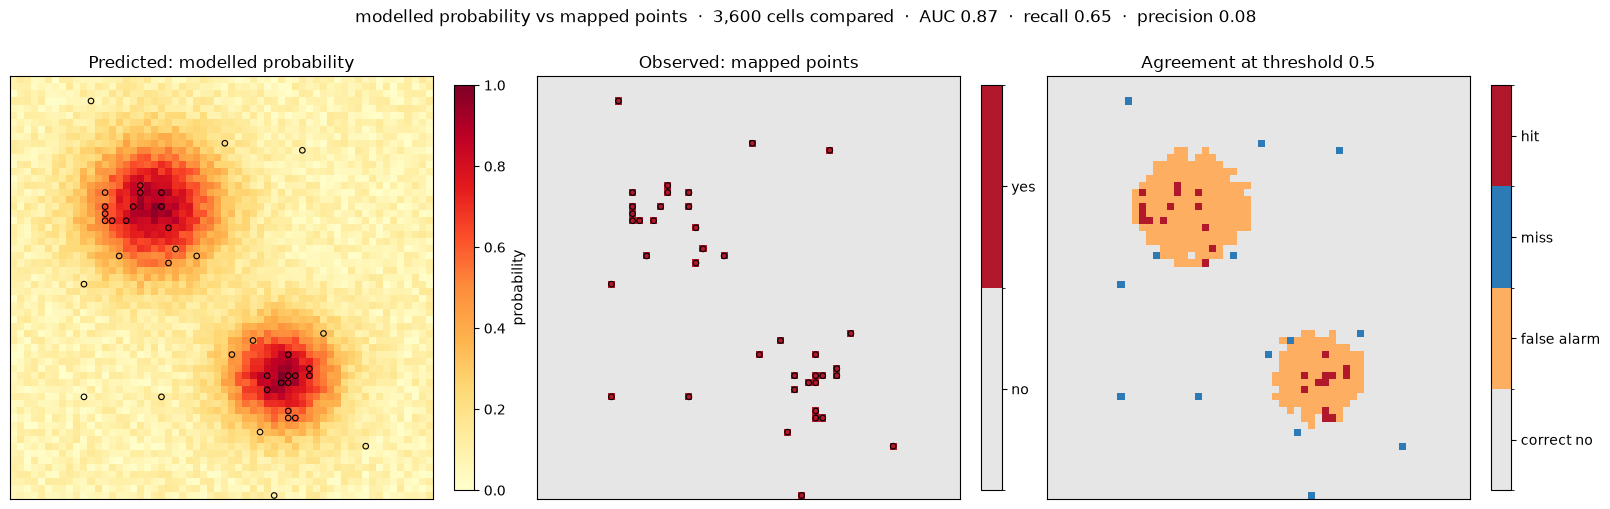

In [8]:
points = gpd.read_file(points_path)
figure = plot_comparison(grid, result, points=points)

## Step 7. Three things you will want next

**Forgive near misses.** A model that puts the hazard one cell away is not as wrong
as one that misses entirely. `tolerance_cells=1` adds recall and precision that
accept an offset of a cell, and keeps the exact numbers alongside.

**Compare against measured change, not points.** Erosion depth is a continuous
layer. Scores must rise towards "yes", so pass `-dz`: more loss, higher score.

**Restrict the area.** `mask=` limits the comparison to the cells you trust, such as
evidence cells plus chosen absence cells.

In [9]:
tolerant = compare_fields_on_grid(grid, predicted, observed, model_spec, points_spec,
                                 tolerance_cells=1)
print("exact recall %.2f, within one cell %.2f"
      % (tolerant.metrics["recall"], tolerant.metrics["recall_within_tolerance"]))

erosion_spec = FieldSpec(name="erosion depth", kind="continuous", units="m",
                         threshold=0.5, sign_convention="positive_is_loss")
erosion = compare_fields_on_grid(grid, -elevation_change, observed, erosion_spec, points_spec)
e = erosion.metrics
print("measured loss vs points: AUC %.3f   95%% CI %.3f to %.3f"
      % (e["roc_auc"], e["roc_auc_ci_low"], e["roc_auc_ci_high"]))

exact recall 0.65, within one cell 0.70
measured loss vs points: AUC 0.866   95% CI 0.771 to 0.925


## Step 8. Run several comparisons at once

Real work is one table of comparisons, not one call. Put them in a list, loop, and
save a CSV. Swap the paths for your own files and the pattern stays the same.

In [10]:
import pandas as pd

tasks = [
    ("model vs points", predicted, observed, model_spec),
    ("measured loss vs points", -elevation_change, observed, erosion_spec),
]

rows = []
for name, prediction, truth, spec in tasks:
    r = compare_fields_on_grid(grid, prediction, truth, spec, points_spec)
    rows.append({
        "comparison": name,
        "cells": int(r.valid_mask.sum()),
        "observed yes": int(r.metrics["true_positive"] + r.metrics["false_negative"]),
        "auc": round(r.metrics["roc_auc"], 3),
        "ci low": round(r.metrics["roc_auc_ci_low"], 3),
        "ci high": round(r.metrics["roc_auc_ci_high"], 3),
        "recall": round(r.metrics["recall"], 2),
        "precision": round(r.metrics["precision"], 2),
    })

table = pd.DataFrame(rows)
table.to_csv(FOLDER / "results.csv", index=False)
table

,comparison,cells,observed yes,auc,ci low,ci high,recall,precision
0,model vs points,3600,40,0.867,0.794,0.917,0.65,0.08
1,measured loss vs points,3600,40,0.866,0.771,0.925,0.68,0.12


## Using your own data

Replace the three paths and keep everything else:

```python
grid, crs = grid_from_raster("my_model.tif", crs="EPSG:6339")
predicted = raster_to_node_field(grid, crs, "my_model.tif", raster_crs="EPSG:6339")
observed = vector_to_node_field(grid, crs, "my_points.shp")
```

Other inputs work the same way:

- **ESRI ASCII (`.asc`)** reads like any raster, but the file carries no CRS, so pass it.
- **Lines and polygons** burn in like points; `all_touched=True` marks every cell they cross.
- **Class codes from a column**: `vector_to_node_field(grid, crs, path, value="class_column")`.
- **A NumPy array** can be passed straight in: 1D in Landlab node order, or 2D with
  `origin="upper"` when row 0 is north, `origin="lower"` when row 0 is south.
- **A field already on the grid**: pass its name as a string.

## The traps this package is built to catch

1. **A shifted grid.** Build grids with `grid_from_raster`, never Landlab's ASCII loader.
2. **A guessed CRS.** You always state it.
3. **An upside-down array.** 2D arrays need `origin`; there is no default.
4. **A silent threshold.** You choose what counts as "yes".
5. **Fill values scored as data.** Use `nodata=` for one value, `valid_range=` for drifting
   flags such as 9999.137. Removed cells are counted in `result.masked_out_of_range`.
6. **False certainty.** The AUC comes with an interval, and a perfect separation reports
   `nan` instead of pretending to be exact.